In [27]:
%pip install geopandas sqlalchemy shapely psycopg2-binary


[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


1. Initial Configuration 

In [42]:
# Import Libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import warnings
import os
import datetime

# Database Configuration 
DB_CONFIG = {
    'host': 'localhost',
    'port': 5433,
    'database': 'layereddb',
    'user': 'anny_llosa',
    'password': 'w3kx79JQeH4T4d4y8' 
}
# Configure the database infrastructure and establish a connection
connection_url = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
engine = create_engine(connection_url)
print("✅ Database engine created successfully.")

# All Tables in the berlin_source_data schema
def get_available_tables(): 
    try:
        query = text("""
            SELECT DISTINCT table_name 
            FROM information_schema.columns 
            WHERE table_schema = 'berlin_source_data' 
            AND column_name = 'geometry'
            ORDER BY table_name
        """)
        with engine.connect() as connection:
            tables_df = pd.read_sql(query, connection)
        return tables_df['table_name'].tolist()
            
    except Exception as e:
        print(f"Connection Error: {e}")
        return[]

#Executive
available_poi_tables = get_available_tables()
results_list_errors = []
non_varchar_found=[]

if available_poi_tables:
    for table in available_poi_tables:
        query_type = text(f"""
            SELECT table_name, data_type 
            FROM information_schema.columns 
            WHERE table_schema = 'berlin_source_data' 
              AND table_name = '{table}' 
              AND column_name = 'geometry'
              AND data_type NOT IN ('character varying', 'varchar', 'USER-DEFINED', 'geometry')
        """)
        
        with engine.connect() as conn:
            res = conn.execute(query_type).fetchone()
            if res:
                error_item = {
                    'table': res[0], 
                    'issue': 'NON_VARCHAR_TYPE', 
                    'details': f"Detected type: {res[1]}. Should be VARCHAR."
                }
                results_list_errors.append(error_item)
                non_varchar_found.append(error_item)

    print(f"✅ {len(available_poi_tables)} tables identified with 'geometry' columns.")
    
    if non_varchar_found:
        print(f"❌ Found {len(non_varchar_found)} tables that are NOT VARCHAR:")
        display(pd.DataFrame(non_varchar_found))
    else:
        print("✅ All tables use the required VARCHAR data type.")
        
    print("-" * 50)
    print("Tables ready for spatial audit:")
    for i, table in enumerate(available_poi_tables, 1):
        print(f"{i:02d}. {table}")
else:
    print("❌ No tables were found. Check the schema name.")

print("-" * 50)

✅ Database engine created successfully.
✅ 44 tables identified with 'geometry' columns.
❌ Found 5 tables that are NOT VARCHAR:


,table,issue,details
0,job_centers,NON_VARCHAR_TYPE,Detected type: text. Should be VARCHAR.
1,long_term_listings,NON_VARCHAR_TYPE,Detected type: text. Should be VARCHAR.
2,schools,NON_VARCHAR_TYPE,Detected type: text. Should be VARCHAR.
3,social_clubs_activities,NON_VARCHAR_TYPE,Detected type: text. Should be VARCHAR.
4,spaetis,NON_VARCHAR_TYPE,Detected type: text. Should be VARCHAR.


--------------------------------------------------
Tables ready for spatial audit:
01. banks
02. bike_lanes
03. bus_stops
04. dental_offices
05. districts
06. doctors
07. emergency_stations
08. exhibition_centers
09. food_markets
10. galleries
11. government_offices
12. gyms
13. hospitals
14. job_centers
15. kindergartens
16. libraries
17. long_term_listings
18. malls
19. milieuschutz_protection_zones
20. museums
21. neighborhoods
22. night_clubs
23. parking_spaces
24. parks
25. petstores
26. pharmacies
27. playgrounds
28. pools
29. post_offices
30. public_artworks
31. recycling_points
32. religious_institutions
33. sbahn
34. schools
35. short_term_listings
36. social_clubs_activities
37. spaetis
38. supermarkets
39. theaters
40. tram_stops
41. ubahn
42. universities
43. venues
44. veterinary_clinics
--------------------------------------------------


In [43]:
#This list will save the findings from all the following blocks.
results_list_errors = []

print("Error collection system ready.")
print("All geometry columns are expected to be stored as VARCHAR.")

Error collection system ready.
All geometry columns are expected to be stored as VARCHAR.


In [44]:
# Initialización
results_list_errors = []

ISSUE_TYPES = {
    'varchar': 'VARCHAR_CONTAINER',    #  geometry,VARCHAR_CONTAINER,Stored as VARCHAR
    'null': 'NULL_VALUES',             #  lat/lon,NULL_VALUES
    'spatial': 'OUTSIDE_BERLIN',       #  geometry,OUTSIDE_BERLIN
    'duplicate': 'DUPLICATE_RECORDS',  #  duplicate records
    'mixed': 'MIXED_GEOMETRIES'        #  type mix (Point/Polygon)
}

print(f"✅ System ready. {len(available_poi_tables)} POI tables will be audited.")
print(f"✅ Strict Criteria: Geometry data_type must be 'character varying'.")
print("Findings will be formatted and stored in 'results_list_errors'.")
print("The findings will be formatted for the 'geometry_audit_findings.csv' file.")

✅ System ready. 44 POI tables will be audited.
✅ Strict Criteria: Geometry data_type must be 'character varying'.
Findings will be formatted and stored in 'results_list_errors'.
The findings will be formatted for the 'geometry_audit_findings.csv' file.


2. Data Type Validation (VARCHAR/TEXT)

In [45]:
# Geometry column that is not of type VARCHAR
query_types = text("""
    SELECT table_name, column_name, data_type
    FROM information_schema.columns 
    WHERE table_schema = 'berlin_source_data' 
      AND column_name IN ('geometry', 'geom_point', 'pt_geom', 'geom_wkt', 'footprint_geom')
      AND data_type NOT IN ('character varying', 'varchar')
    ORDER BY table_name
""")

with engine.connect() as conn:
    non_varchar_tables = pd.read_sql(query_types, conn)

if non_varchar_tables.empty:
    print("✅ All geometry columns are VARCHAR(character varying)")
else:
    print(f"❌ {len(non_varchar_tables)} tables with geometry NOT VARCHAR:")
    for index, row in non_varchar_tables.iterrows():
        results_list_errors.append({'table': row['table_name'], 'issue': 'NON_VARCHAR_TYPE', 'details': f"Column '{row['column_name']}' is of type {row['data_type']}"
        })
    display(non_varchar_tables)
print(f"AUDIT COMPLETE: Found {len(non_varchar_tables)} Tables that do not conform to the VARCHAR type.")

❌ 15 tables with geometry NOT VARCHAR:


,table_name,column_name,data_type
0,bike_lanes,geometry,USER-DEFINED
1,bus_stops,geometry,USER-DEFINED
2,districts,geometry,USER-DEFINED
3,government_offices,geometry,USER-DEFINED
4,gyms,geometry,USER-DEFINED
5,job_centers,geometry,text
6,libraries,geometry,USER-DEFINED
7,long_term_listings,geometry,text
8,milieuschutz_protection_zones,geometry,USER-DEFINED
9,neighborhoods,geometry,USER-DEFINED


AUDIT COMPLETE: Found 15 Tables that do not conform to the VARCHAR type.


In [46]:
# AUDIT: Tables that are NOT DECIMAL(9,6)
query_types = text("""
SELECT 
    table_name, 
    column_name, 
    data_type,
    numeric_precision,
    numeric_scale
FROM information_schema.columns 
WHERE table_schema = 'berlin_source_data' 
  AND (column_name ILIKE '%lat%' OR column_name ILIKE '%lon%')
  AND (
      data_type NOT IN ('decimal', 'numeric') 
      OR numeric_precision != 9 
      OR numeric_scale != 6
  )
ORDER BY table_name;
""")
with engine.connect() as conn:
    invalid_coord_cols = pd.read_sql(query_types, conn)


In [47]:
invalid_coord_cols

,table_name,column_name,data_type,numeric_precision,numeric_scale
0,banks,longitude,numeric,10,6.0
1,banks,latitude,numeric,10,6.0
2,food_markets,latitude,numeric,10,7.0
3,food_markets,longitude,numeric,10,7.0
4,job_centers,latitude,double precision,53,NaN
5,job_centers,longitude,double precision,53,NaN
6,milieuschutz_protection_zones,longitude,numeric,10,6.0
7,milieuschutz_protection_zones,latitude,numeric,10,6.0


- MISSING DATA

In [48]:
# Audit of missing values (NULL or Empty)
missing_data = []

for current_table in available_poi_tables:
    query = text(f"""
        SELECT 
            '{current_table}' AS table_name,
            COUNT(*) FILTER (WHERE geometry IS NULL OR CAST(geometry AS TEXT) = '') AS missing_geometry,
            COUNT(*) FILTER (WHERE latitude IS NULL OR longitude IS NULL) AS missing_coords
        FROM berlin_source_data.{current_table}
    """)

    try:
        with engine.connect() as conn:
            res = pd.read_sql(query, conn)
        if (res.iloc[0]['missing_geometry'] > 0) or (res.iloc[0]['missing_coords'] > 0):
            missing_data.append(res)
            results_list_errors.append({'table': current_table, 'issue': 'MISSING_DATA', 'details': f"Geo NULL: {res.iloc[0]['missing_geometry']}"
            })                               
    except Exception as e:
        continue

print("Missing Data Report")
print("="*50)  

if missing_data:  
    df_missing_final = pd.concat(missing_data, ignore_index=True)
    display(df_missing_final)
else:
    print("✅ All checked tables are free of NULL values.")

Missing Data Report


,table_name,missing_geometry,missing_coords
0,bike_lanes,0,78833


- COORDIANTE RANGE

In [58]:
# Bounding Box for Berlin: Lat ~ 52.3 to 52.7 | Lon ~ 13.0 to 13.8
subset_range_check = ['short_term_listings', 'parking_spaces']
range_issues = []

print(f"Checking coordinates out of range (Berlin)")

for current_table in subset_range_check:
    query = text(f"""
        SELECT '{current_table}' AS table_name, COUNT(*) AS total_errors
        FROM berlin_source_data.{current_table}
        WHERE (latitude NOT BETWEEN 52.3 AND 52.7)
           OR (longitude NOT BETWEEN 13.0 AND 13.8)
           OR latitude IS NULL 
           OR longitude IS NULL
    """)

    try:
        with engine.connect() as conn:
            res = pd.read_sql(query, conn)
            if res.iloc[0]['total_errors'] > 0:
                range_issues.append(res)
                results_list_errors.append({'table': current_table, 'issue': 'COORD_OUT_RANGE'})
    except Exception as e:
        continue   

if range_issues:
    print(f"❌ {len(range_issues)} tables with coordinate issues were detected:")
    display(pd.concat(range_issues, ignore_index=True))
else:
    print("✅ All numeric coordinates are within the allowed range for Berlin.")

Checking coordinates out of range (Berlin)
✅ All numeric coordinates are within the allowed range for Berlin.


- GEOMETRY TYPE VALIDATION

In [57]:
# GEOMETRY TYPE VALIDATION
geometry_type_report = []

for current_table in available_poi_tables:
    query = text(f"""
        SELECT 
            '{current_table}' AS table_name, 
            ST_GeometryType(geometry::geometry) AS detected_type,
            COUNT(*) AS total_records
        FROM berlin_source_data.{current_table}
        WHERE geometry IS NOT NULL AND geometry::text != ''
        AND ST_GeometryType(geometry::geometry) != 'ST_Point'
        GROUP BY detected_type
        
    """)

    try:
        with engine.connect() as conn:
            res = pd.read_sql(query, conn)
            if not res.empty:
                geometry_type_report.append(res)
                
                # If the table is of POIs but detects 'ST_Polygon'
                for _, row in res.iterrows():
                    if row['detected_type'] != 'ST_Point':
                        results_list_errors.append({
                            'table': current_table, 
                            'issue': 'UNEXPECTED_GEOM_TYPE', 
                            'details': f"Detected {row['detected_type']} ({row['total_records']} records). Expected ST_Point."
                        })
    except Exception as e:
        print(f"Error checking types in {current_table}: {e}")

if geometry_type_report:
    display(pd.concat(geometry_type_report, ignore_index=True))

,table_name,detected_type,total_records
0,bike_lanes,ST_MultiLineString,78833
1,districts,ST_MultiPolygon,12
2,job_centers,ST_Polygon,16
3,milieuschutz_protection_zones,ST_MultiPolygon,175
4,neighborhoods,ST_MultiPolygon,96
5,parking_spaces,ST_Polygon,53232
6,parking_spaces,ST_LineString,20
7,parking_spaces,ST_MultiPolygon,255510
8,short_term_listings,ST_MultiPolygon,14187


In [59]:
# GEOMETRIC VALIDITY (ST_IsValidDetail) 
malformed_issues = []

for current_table in available_poi_tables:
    query = text(f"""
        SELECT 
            '{current_table}' AS table_name,
            (valid_detail).valid AS is_valid,
            (valid_detail).reason AS reason,
            (valid_detail).location AS location_error,
            COUNT(*) AS total_occurrences
        FROM (
            SELECT ST_IsValidDetail(geometry::geometry) AS valid_detail
            FROM berlin_source_data.{current_table}
            WHERE geometry IS NOT NULL AND geometry::text != ''
        ) AS subquery
        WHERE (valid_detail).valid = false
        GROUP BY is_valid, reason, location_error
    """)

    try:
        with engine.connect() as conn:
            res = pd.read_sql(query, conn)
            
            if not res.empty:
                malformed_issues.append(res)
                for _, row in res.iterrows():
                    results_list_errors.append({
                        'table': current_table, 
                        'issue': 'GEOMETRY_INVALID', 
                        'details': f"Reason: {row['reason']} at {row['location_error']}"
                    })
                print(f" ❌ {current_table}: Found {res['total_occurrences'].sum()} invalid geometries.")
            else:
                print(f"  ✅ {current_table}: Geometries are structurally sound.")
    except Exception as e:
        print(f"Critical Parsing Error in {current_table}: Check if WKT is readable.")
        results_list_errors.append({
            'table': current_table, 
            'issue': 'WKT_PARSING_FAILED', 
            'details': str(e)
        })

if malformed_issues:
    print("\n--- Summary: Malformed Geometries Detailed Report ---")
    display(pd.concat(malformed_issues, ignore_index=True))

  ✅ banks: Geometries are structurally sound.
  ✅ bike_lanes: Geometries are structurally sound.
  ✅ bus_stops: Geometries are structurally sound.
  ✅ dental_offices: Geometries are structurally sound.
  ✅ districts: Geometries are structurally sound.
  ✅ doctors: Geometries are structurally sound.
  ✅ emergency_stations: Geometries are structurally sound.
  ✅ exhibition_centers: Geometries are structurally sound.
  ✅ food_markets: Geometries are structurally sound.
  ✅ galleries: Geometries are structurally sound.
  ✅ government_offices: Geometries are structurally sound.
  ✅ gyms: Geometries are structurally sound.
  ✅ hospitals: Geometries are structurally sound.
  ✅ job_centers: Geometries are structurally sound.
  ✅ kindergartens: Geometries are structurally sound.
  ✅ libraries: Geometries are structurally sound.
  ✅ long_term_listings: Geometries are structurally sound.
  ✅ malls: Geometries are structurally sound.
  ✅ milieuschutz_protection_zones: Geometries are structurally s

In [60]:
# Geographic consistency validation (ST_Within)in_query

spatial_outliers = []

try:
    with engine.connect() as conn:
        berlin_boundary = conn.execute(text("SELECT ST_Union(geometry) FROM berlin_source_data.districts")).scalar()
        print("Berlin boundary loaded. Starting spatial audit...")

        for current_table in available_poi_tables:
            query = text(f"""
                SELECT '{current_table}' AS table_name, 
                        COUNT(*) AS points_outside
                FROM berlin_source_data.{current_table}
                WHERE geometry IS NOT NULL 
                  AND geometry::text != ''
                  AND NOT ST_Within(
                      ST_SetSRID(geometry::geometry, 4326), 
                      ST_SetSRID(CAST(:boundary AS geometry), 4326)
                  )
            """)
            
            res = pd.read_sql(query, conn, params={"boundary": berlin_boundary})
            count = int(res.iloc[0]['points_outside'])
            
            if count > 0:
                spatial_outliers.append(res)
                results_list_errors.append({'table': current_table, 'issue': 'OUTSIDE_BERLIN', 'details': f"Found {count} records outside the official city boundaries."
                })
    
except Exception as e:
    print(f"❌ Validation error: {e}")
if spatial_outliers:
        print("\n--- Summary: Points Outside Berlin ---")
        display(pd.concat(spatial_outliers, ignore_index=True))

Berlin boundary loaded. Starting spatial audit...

--- Summary: Points Outside Berlin ---


,table_name,points_outside
0,bike_lanes,92
1,long_term_listings,1
2,milieuschutz_protection_zones,4
3,neighborhoods,36
4,parking_spaces,30
5,short_term_listings,782


🚀 Starting Batch Spatial Analysis...
📊 Processing: short_term_listings...


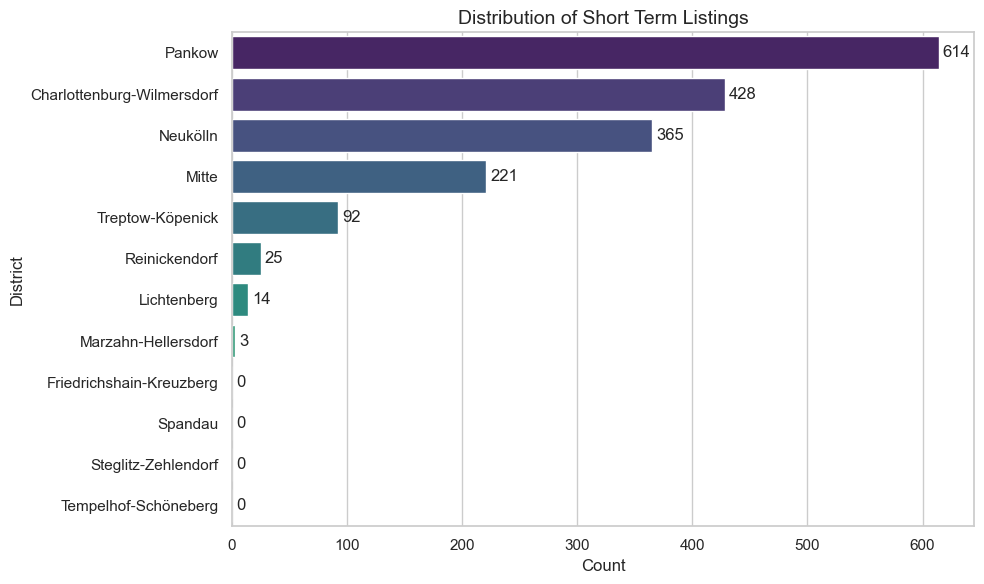

📊 Processing: parking_spaces...


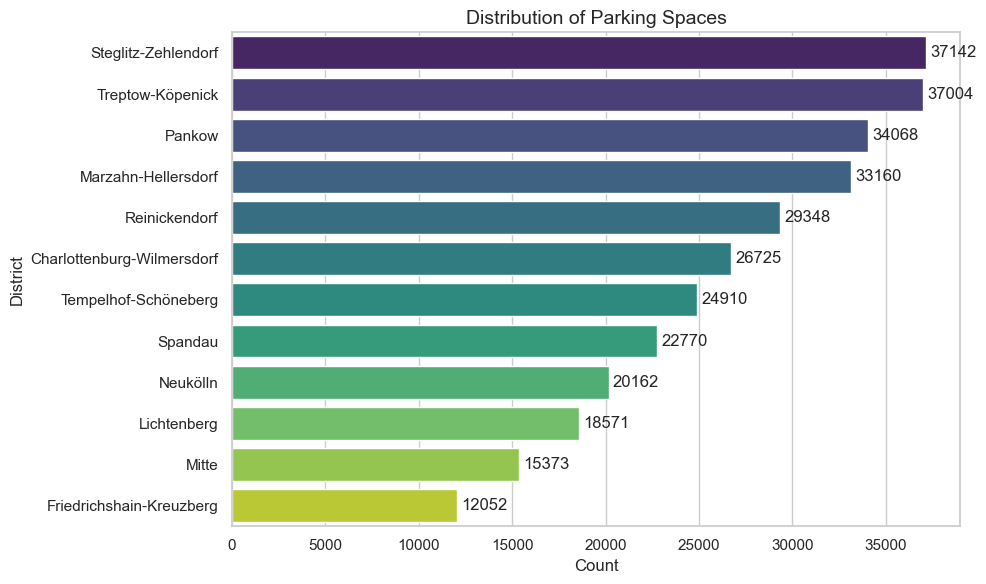

✅ All analyses completed successfully.


In [27]:
import pandas as pd
from sqlalchemy import text
import matplotlib.pyplot as plt
import seaborn as sns

districts_table = "districts"
name_column = "district"
subset_range_check = ['short_term_listings', 'parking_spaces'] 

print("🚀 Starting Batch Spatial Analysis...")

try:
    with engine.connect() as conn:
        for table in subset_range_check:
            print(f"📊 Processing: {table}...")
            
            query = text(f"""
                SELECT 
                    TRIM(d.{name_column}) AS district,
                    COUNT(p.id) AS total_points
                FROM berlin_source_data.{districts_table} d
                LEFT JOIN berlin_source_data.{table} p ON ST_Within(
                    ST_SetSRID(p.geometry::geometry, 4326), 
                    ST_SetSRID(d.geometry::geometry, 4326)
                )
                GROUP BY d.{name_column}
                ORDER BY total_points DESC
            """)
            
            df_result = pd.read_sql(query, conn)
            
            # Visualization
            plt.figure(figsize=(10, 6))
            sns.set_theme(style="whitegrid")
            
            ax = sns.barplot(
                data=df_result, 
                x='total_points', 
                y='district', 
                hue='district',
                palette='viridis',
                legend=False
            )
            
            plt.title(f'Distribution of {table.replace("_", " ").title()}', fontsize=14)
            plt.xlabel('Count')
            plt.ylabel('District')
            
            # Add labels to bars
            for i in ax.containers:
                ax.bar_label(i, padding=3)
            
            plt.tight_layout()
            plt.show()
            

    print("✅ All analyses completed successfully.")

except Exception as e:
    print(f"❌ Critical Error: {e}")

BLOCK: FINAL REPORT & EXPORT

✅ Audit report saved as 'geometry_audit_findings.csv'


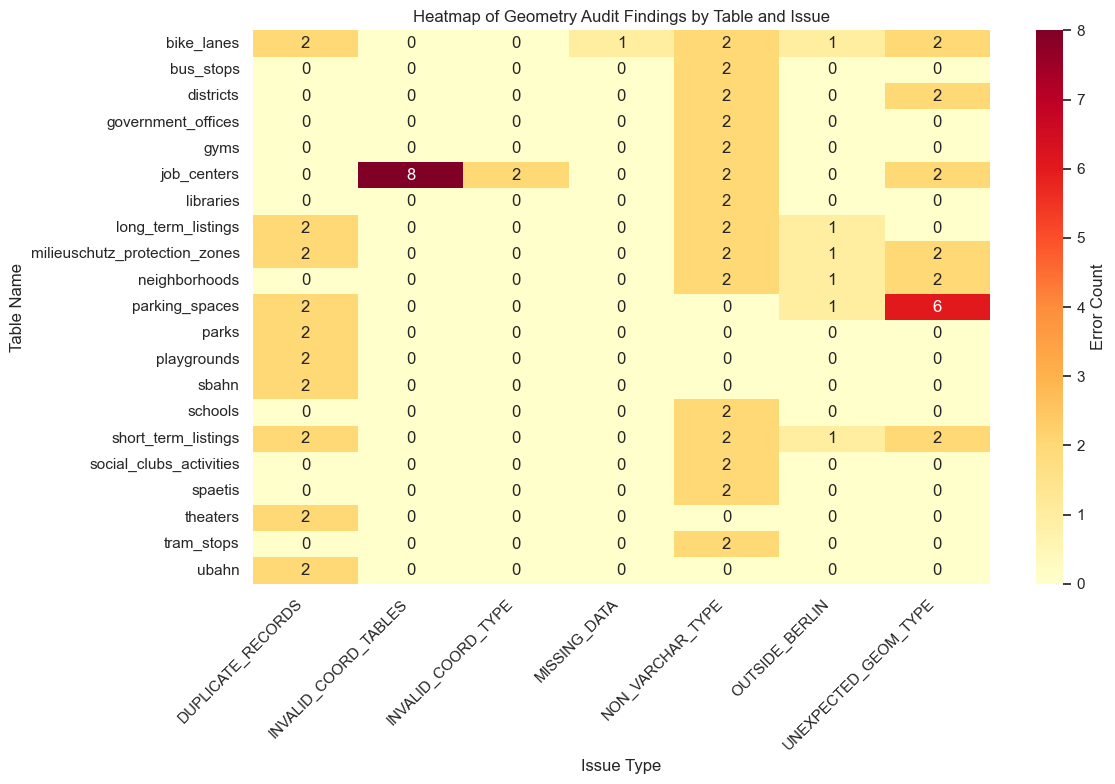


Top Audit Findings Summary


,table,issue,details
0,bike_lanes,NON_VARCHAR_TYPE,Column 'geometry' is of type USER-DEFINED
1,bus_stops,NON_VARCHAR_TYPE,Column 'geometry' is of type USER-DEFINED
2,districts,NON_VARCHAR_TYPE,Column 'geometry' is of type USER-DEFINED
3,government_offices,NON_VARCHAR_TYPE,Column 'geometry' is of type USER-DEFINED
4,gyms,NON_VARCHAR_TYPE,Column 'geometry' is of type USER-DEFINED
5,job_centers,NON_VARCHAR_TYPE,Column 'geometry' is of type text
6,libraries,NON_VARCHAR_TYPE,Column 'geometry' is of type USER-DEFINED
7,long_term_listings,NON_VARCHAR_TYPE,Column 'geometry' is of type text
8,milieuschutz_protection_zones,NON_VARCHAR_TYPE,Column 'geometry' is of type USER-DEFINED
9,neighborhoods,NON_VARCHAR_TYPE,Column 'geometry' is of type USER-DEFINED


In [28]:
import seaborn as sns

if results_list_errors:
    df_final_report = pd.DataFrame(results_list_errors)
    
    final_csv = "geometry_audit_findings.csv"
    df_final_report.to_csv(final_csv, index=False)
    print(f"✅ Audit report saved as '{final_csv}'")

    plt.figure(figsize=(12, 8))
    error_matrix = df_final_report.groupby(['table', 'issue']).size().unstack(fill_value=0)
    
    sns.heatmap(error_matrix, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Error Count'})
    plt.title("Heatmap of Geometry Audit Findings by Table and Issue")
    plt.xlabel("Issue Type")
    plt.ylabel("Table Name")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\nTop Audit Findings Summary")
    display(df_final_report.head(10))
else:
    print("✅ Amazing! No errors were found in any table.")

In [29]:
all_spatial_errors = []
available_poi_tables = ['short_term_listings', 'long_term_listings', 'parking_spaces']

try:
    with engine.connect() as conn:
        for current_table in available_poi_tables:
            print(f"Investigating out-of-bounds records in: {current_table}...")
            
            # Use ST_Point
            query = text(f"""
                SELECT 
                    '{current_table}' AS table_name,
                    id,
                    latitude, 
                    longitude 
                FROM berlin_source_data.{current_table}
                WHERE latitude IS NOT NULL AND longitude IS NOT NULL
                    AND NOT ST_Within(
                        ST_SetSRID(ST_Point(longitude, latitude), 4326), 
                        (SELECT ST_SetSRID(ST_Union(geometry), 4326) FROM berlin_source_data.districts)
                    )
            """)

            df_err = pd.read_sql(query, conn)
            if not df_err.empty:
                all_spatial_errors.append(df_err)

    if all_spatial_errors:
        df_final_errors = pd.concat(all_spatial_errors, ignore_index=True)
        print(f"\n✅ {len(df_final_errors)} real errors have been extracted for inspection.")
        display(df_final_errors.head(20))
    
except Exception as e:
    print(f"Error extracting details: {e}")

Investigating out-of-bounds records in: short_term_listings...
Investigating out-of-bounds records in: long_term_listings...
Investigating out-of-bounds records in: parking_spaces...


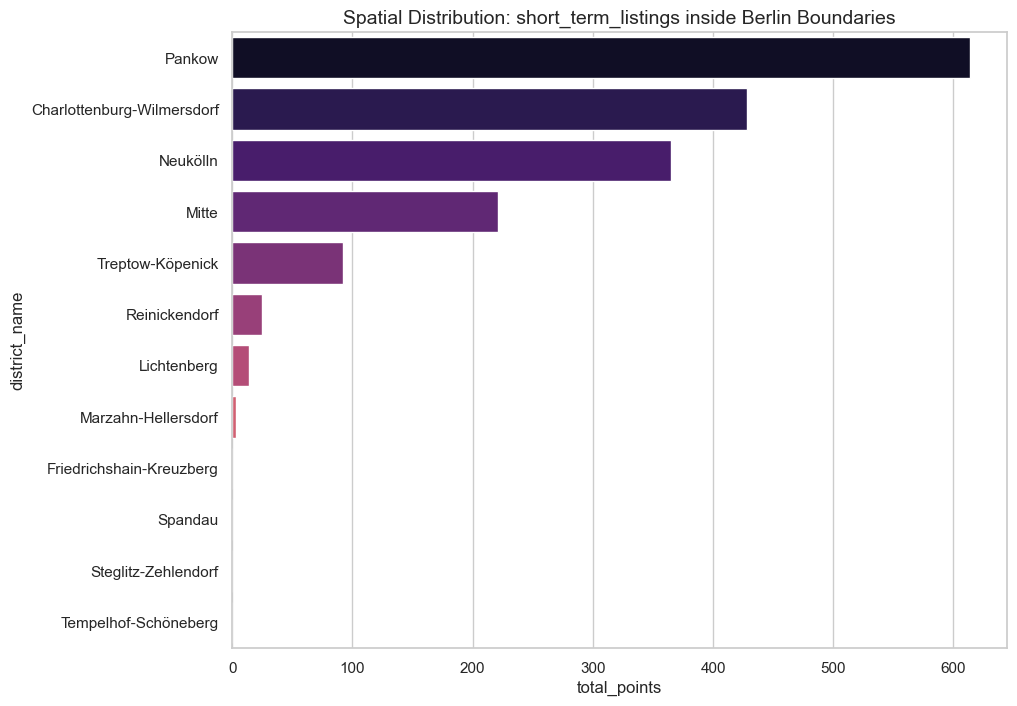

,district_name,total_points
0,Pankow,614
1,Charlottenburg-Wilmersdorf,428
2,Neukölln,365
3,Mitte,221
4,Treptow-Köpenick,92
5,Reinickendorf,25
6,Lichtenberg,14
7,Marzahn-Hellersdorf,3
8,Friedrichshain-Kreuzberg,0
9,Spandau,0


In [30]:
# Final Spatial Validation & Distribution 
target_table = 'short_term_listings' 

try:
    with engine.connect() as conn:
        # 1. Identify valid column name (Requirement: Document scripts used)
        columns_query = text("SELECT column_name FROM information_schema.columns WHERE table_name = 'districts' AND table_schema = 'berlin_source_data'")
        cols = [row[0] for row in conn.execute(columns_query)]
        
        possible_names = ['district', 'name', 'district_name']
        name_col = next((c for c in cols if c in possible_names), cols[0])

        # 2. Validating points actually inside Berlin boundaries (Task Objective)
        query_density = text(f"""
            SELECT 
                d.{name_col} AS district_name,
                COUNT(p.id) AS total_points
            FROM berlin_source_data.districts d
            LEFT JOIN berlin_source_data.{target_table} p ON ST_Within(
                ST_SetSRID(p.geometry::geometry, 4326), 
                ST_SetSRID(d.geometry::geometry, 4326)
            )
            GROUP BY d.{name_col}
            ORDER BY total_points DESC
        """)

        df_density = pd.read_sql(query_density, conn)
        
        # 3. Visualization for the report
        plt.figure(figsize=(10, 8))
        sns.barplot(data=df_density, x='total_points', y='district_name', hue='district_name', palette='magma', legend=False)
        plt.title(f'Spatial Distribution: {target_table} inside Berlin Boundaries', fontsize=14)
        plt.show()
        
        display(df_density)

except Exception as e:
    print(f"Validation Script Error: {e}")

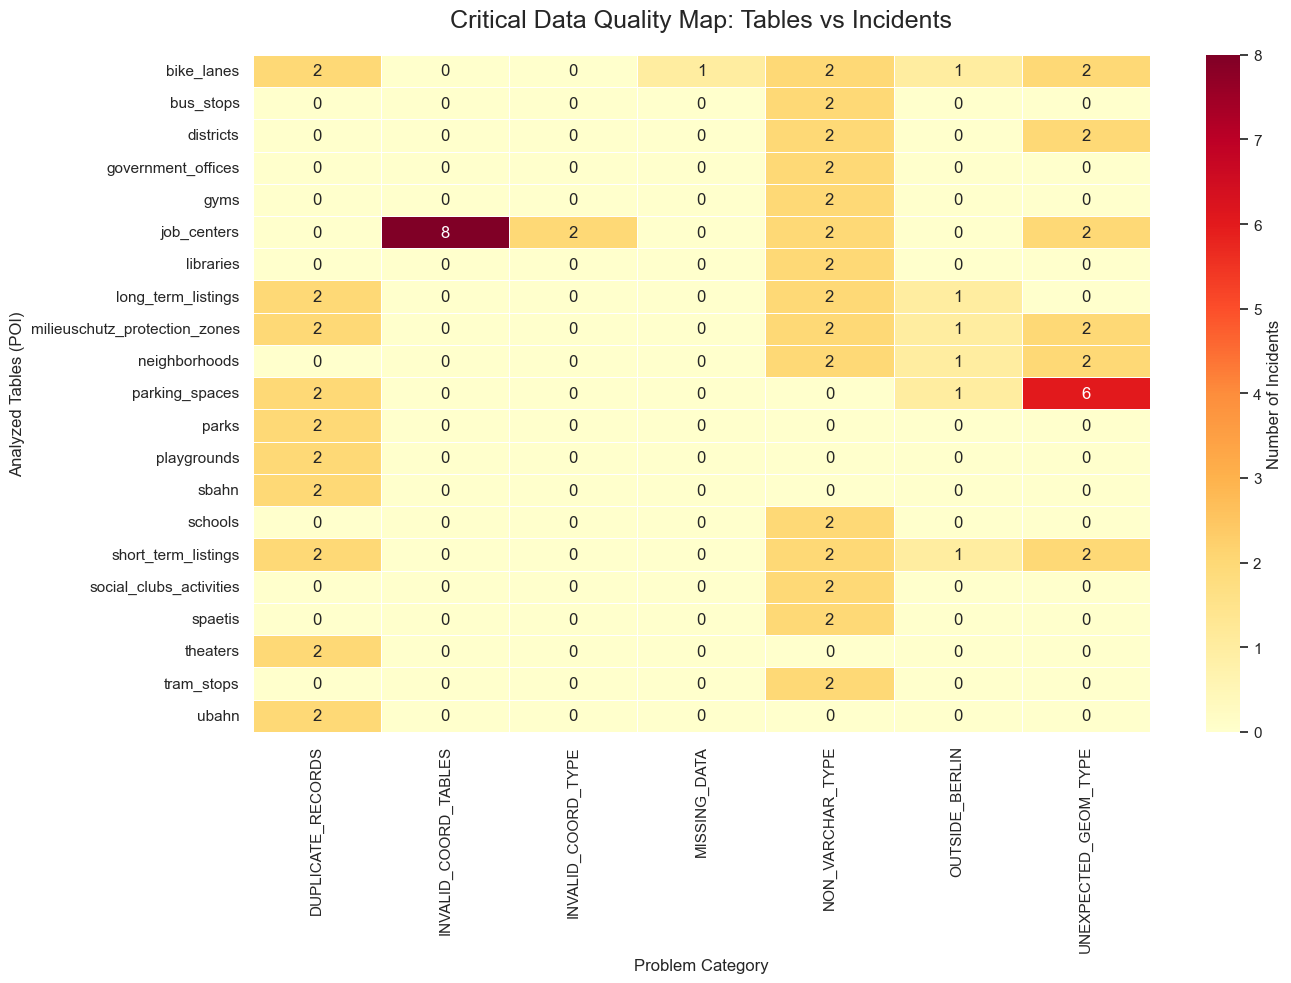

In [31]:
# TABLE INTEGRITY HEATMAP
if results_list_errors:
    audit_pivot = pd.DataFrame(results_list_errors)
    
    heatmap_data = pd.crosstab(audit_pivot['table'], audit_pivot['issue'])

    plt.figure(figsize=(14, 10))
    sns.set_theme(style="white")
    
    # Visualization : Color map highlighting errors (Reds/Oranges)
    sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd",      
        cbar_kws={'label': 'Number of Incidents'}, linewidths=.5
    )

    plt.title('Critical Data Quality Map: Tables vs Incidents', fontsize=18, pad=20)
    plt.xlabel('Problem Category', fontsize=12)
    plt.ylabel('Analyzed Tables (POI)', fontsize=12)
    
    plt.tight_layout()
    plt.show()

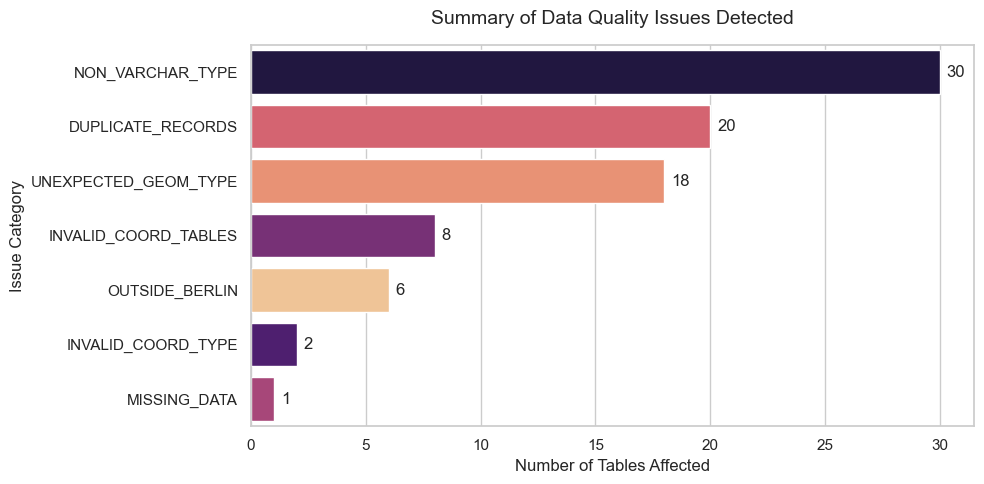

In [ ]:
# Final Audit Summary Visualization 
# Objective: Visualize the frequency of different issue types across all tables.

summary_df = pd.DataFrame(results_list_errors)

if not summary_df.empty:
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")
    
    ax = sns.countplot(
        data=summary_df, 
        y='issue', 
        hue='issue', 
        palette='magma', 
        legend=False, 
        order=summary_df['issue'].value_counts().index
    )
    
    plt.title('Summary of Data Quality Issues Detected', fontsize=14, pad=15)
    plt.xlabel('Number of Tables Affected')
    plt.ylabel('Issue Category')
    
    # Add labels to the bars
    for container in ax.containers:
        ax.bar_label(container, padding=5)
    
    plt.tight_layout()
    plt.show()
else:
    print(" Excellent! No problems were detected in any category.")